## CNN Training

Train a CNN network to extract the needle position of an analog pointer

### Basic Parameter

IMPORTANT: Do not rename any variables in this section — they are externally referenced in the GitHub action `Train Model`.

* `TFlite_MainType`: Indicates the model type. Used in folder structures and the final model file name
* `TFlite_Version`: Version identifier for the model. Used in folder structures and the final model file name
* `TFlite_Size`: Defines the specific model architecture used for training. (Available models: `./src/utils/ana_cont_models.py`)
* `Validation_Percentage`: Fraction of images reserved for validation. Example: 0.2 means 20% of the dataset is used for validation
* `Input_Dir`: Path to the input directory containing training images
* `Output_Dir`: Path to the output directory where results (models, logs, etc.) will be saved
* `Input_Shape`: Tuple specifying the image dimensions (width, height, channels)

In [1]:
# Model naming
TFlite_MainType: str = 'ana-cont'
TFlite_Version: str  = 'undefined'
TFlite_Size: str     = 's0'

# Validation size
# Note: 0.0 = 0% validation size, use all images for training
Validation_Percentage = 0.2

# Folders
Input_Dir: str  = 'data_resize_all'
Output_Dir: str = 'models/ana-cont'

# Input image size [width, height, channels]
Input_Shape = (32, 32, 3)


In [2]:
# Parameters
TFlite_Version = "tests3"
TFlite_Size = "s3"
Output_Dir = "models_tmp"


### Load Libaries

In [3]:
import os
import sys
import glob
from pathlib import Path
import random
import math
import numpy as np
import pandas as pd

from PIL import Image 

import tensorflow as tf
from src.models.ana_cont import *

from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
from src.utils.plot_functions import plot_dataset_analog, plot_dataset_analog_result, plot_divergence


%matplotlib inline
np.set_printoptions(precision=4)
np.set_printoptions(suppress=True)


# Make sure version is 4 characters long if version is defined as int (e.g. papermill paramter 100 -> 0100)
if isinstance(TFlite_Version, int):
    TFlite_Version = str(TFlite_Version).zfill(4)


# Validate model size input
VALID_TFLITE_SIZES = {'s0', 's1', 's2', 's3'}
if TFlite_Size not in VALID_TFLITE_SIZES:
    raise ValueError(f"Invalid TFlite_Size '{TFlite_Size}'. Must be one of: {', '.join(VALID_TFLITE_SIZES)}")


# Prepare folders
if not (Path(Input_Dir).exists() and Path(Input_Dir).is_dir()): # Check if input is availabe
    sys.exit(f"Folder '{Input_Dir}' does not exist.")
    
Path(Output_Dir).mkdir(parents=True, exist_ok=True)  # Create output folder if it doesn't exist


# Disable GPUs
try:
    tf.config.set_visible_devices([], 'GPU')
    visible_devices = tf.config.get_visible_devices()
    for device in visible_devices:
        assert device.device_type != 'GPU'
except:
    # Invalid device or cannot modify virtual devices once initialized.
    pass


2025-05-26 19:16:58.642519: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-05-26 19:16:58.645604: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-05-26 19:16:58.654006: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1748287018.667855    2224 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1748287018.672049    2224 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-05-26 19:16:58.687392: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU ins

2025-05-26 19:17:00.931976: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


### Load images

* The images are expected in the "Input_Dir"
* The image size must be 32 x 32 with 3 color channels (RGB)
* The first 3 digits of image filename must contain the real value representation of the image:
  * Generic: `x.y_zzzz.jpg`
  * Example: `4.6_main_ana1_2019-06-02T050011.jpg`

    |Filename Part| Meaning                      | Usage                    |
    |-------------|------------------------------|--------------------------|
    | x.y         | Represented value (e.g. 4.6) | **Value to be learned**  |
    | _zzzz       | Further file description     | Not required / processed |

* The images are stored in the x_data[]
* The expected output for each image in the corresponding y_data[]
  * The periodic nature is reflected in a **sin/cos coding**, which allows to restore the angle/counter value with an arctan later on.
* The last step is a shuffle (from sklearn.utils) as the filenames are on order due to the encoding of the expected analog readout in the filename
* Split dataset into training and validation parts

In [4]:
# Load files
files = glob.glob(f"{Input_Dir}/*.jpg")
num_files = len(files)

# Prepare data containers
f_data = np.empty(num_files, dtype="<U250")
x_data = np.empty((num_files, Input_Shape[0], Input_Shape[1], Input_Shape[2]), dtype="float32")
y_data = np.empty((num_files, 2), dtype="float32")
y_data_target = np.empty(num_files)

# Process files
for i, file in enumerate(files):
    image = Image.open(file)
    image = np.array(image, dtype="float32") # No resizing, use already resized images

    # Extract real value from filename and calculate respective sin/cos values
    base = Path(file).name
    target_number = float(base[:3]) / 10
    target_sin = math.sin(target_number * math.pi * 2)
    target_cos = math.cos(target_number * math.pi * 2)

    # Save data
    f_data[i] = file
    x_data[i] = image
    y_data[i] = [target_sin, target_cos]
    y_data_target[i] = target_number

# Shuffle data
x_data, y_data, y_data_target, f_data = shuffle(x_data, y_data, y_data_target, f_data)

# Split data to train and validation data
x_train, x_test, y_train, y_test = train_test_split(x_data, y_data, test_size=Validation_Percentage)


print("Data count: ", len(y_data))
print(x_data.shape)
print(y_data.shape)


Data count:  1739
(1739, 32, 32, 3)
(1739, 2)


### Distribution of the data

Uneven distribution of data can lead to poorer results.

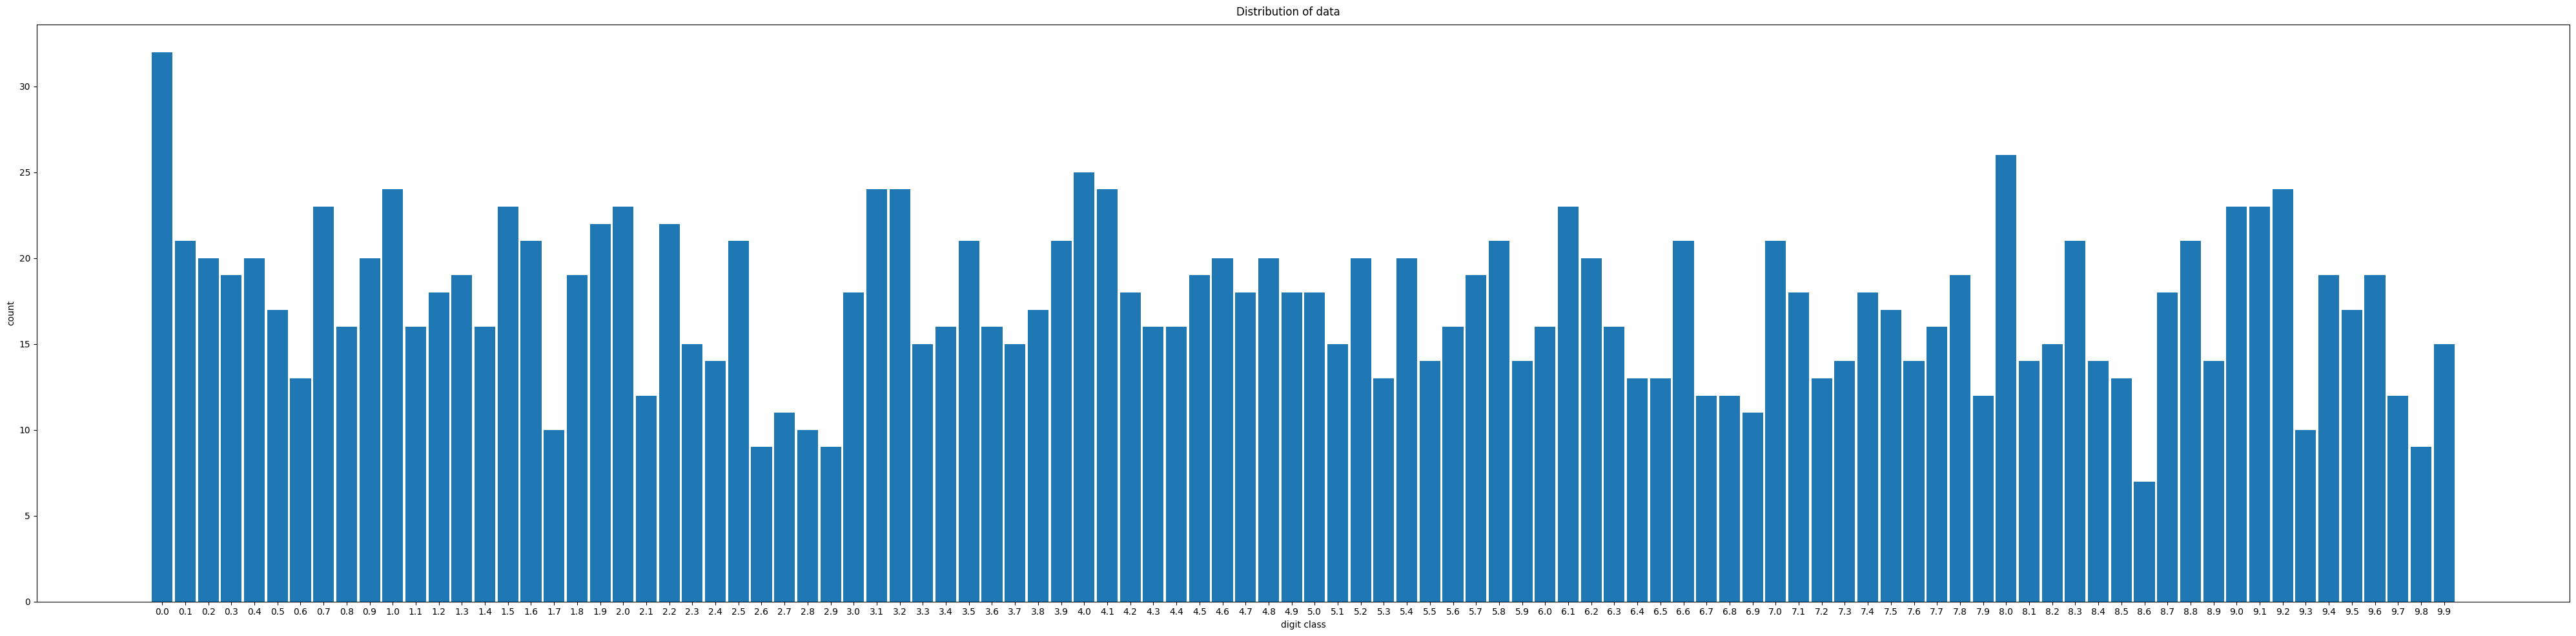

In [5]:
_, inverse = np.unique(y_data_target, return_inverse=True)
ziffer_bincount = np.bincount(inverse)
fig = plt.figure(figsize=(40, 10))
fig.suptitle("Distribution of data")
plt.bar(np.arange (0, 100/10, 0.1), ziffer_bincount, width=0.09, align='center')
plt.ylabel('count')
plt.xlabel('digit class')
plt.tight_layout()
_ = plt.xticks(np.arange(0, 100/10, 0.1))


### Model Definition

#### Important
* Shape of the input layer: (32, 32, 3)
* Shape of the output layer: (2) - sin and cos

In [6]:
if (TFlite_Size == "s0"):
    model = model_ana_cont_s0(input_shape=(Input_Shape[0], Input_Shape[1], Input_Shape[2]), learning_rate=1e-3)
elif (TFlite_Size == "s1"):
    model = model_ana_cont_s1(input_shape=(Input_Shape[0], Input_Shape[1], Input_Shape[2]), learning_rate=1e-3)
elif (TFlite_Size == "s2"):
    model = model_ana_cont_s2(input_shape=(Input_Shape[0], Input_Shape[1], Input_Shape[2]), learning_rate=1e-3)
elif (TFlite_Size == "s3"):
    model = model_ana_cont_s3(input_shape=(Input_Shape[0], Input_Shape[1], Input_Shape[2]), learning_rate=1e-3)
else:
    raise ValueError(f"TFlite_Size: '{TFlite_Size}' is not supported.")


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 3)      │            12 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 4, 4, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 4, 4, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 2, 2, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,830 (136.05 KB)

 Trainable params: 34,408 (134.41 KB)

 Non-trainable params: 422 (1.65 KB)

### Augmentation / Prepare Datasets

Training data


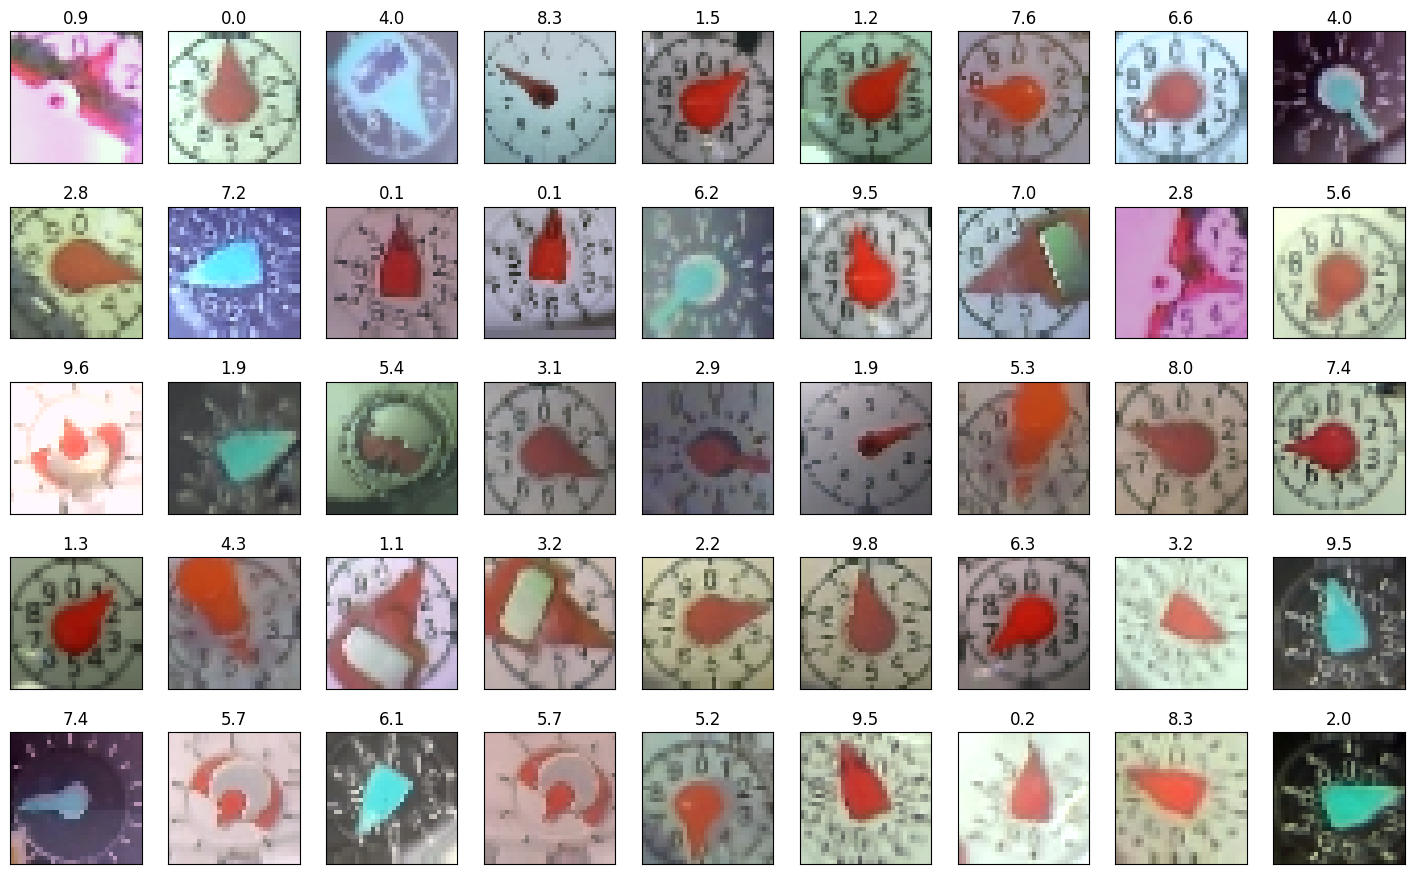

  
Validation data


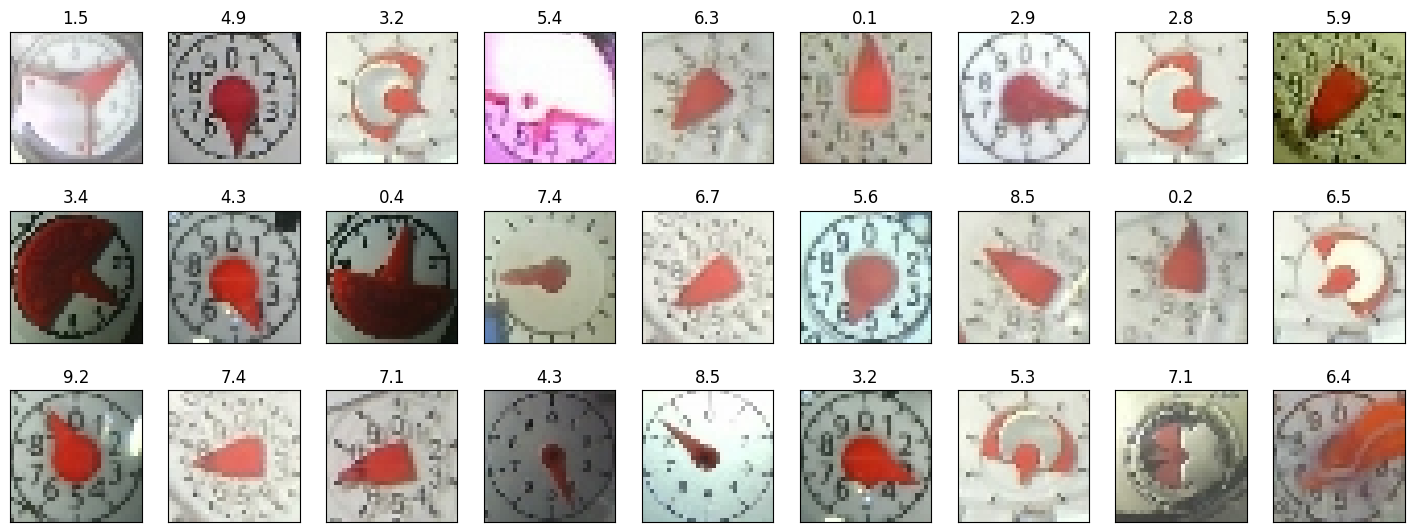

In [7]:
# Parameter
Batch_Size = 8
Shift_Range = 1
Brightness_Range = 0.2
Zoom_Range = 0.05


def random_invert_image(x, probability_invert=0.2):
    """
    Invert an image with a given probability
    """
    if random.random() > probability_invert:
        return x
    return 255 - x  # Invert image

def random_white_balance(x, strength_range=(0.9, 1.1)):
    """
    Simulates poor white balance by randomly scaling RGB channels independently.
    strength_range controls how strong the color cast distortion is.
    """
    x = x.astype(np.float32)

    # Random scaling for each channel (simulates color cast)
    r_scale = np.random.uniform(*strength_range)
    g_scale = np.random.uniform(*strength_range)
    b_scale = np.random.uniform(*strength_range)

    x[..., 0] *= r_scale  # Red channel
    x[..., 1] *= g_scale  # Green channel
    x[..., 2] *= b_scale  # Blue channel

    return x

def preprocessing(x):
    x = random_invert_image(x)
    x = random_white_balance(x)
    x = np.clip(x, 0.0, 255.0)
    return x.astype(np.float32)

# Training data
print("Training data")
datagen = ImageDataGenerator(width_shift_range=[-Shift_Range, Shift_Range], 
                             height_shift_range=[-Shift_Range, Shift_Range],
                             brightness_range=[1 - Brightness_Range, 1 + Brightness_Range],
                             zoom_range=[1 - Zoom_Range, 1 + Zoom_Range],
                             channel_shift_range=5,
                             shear_range=1,
                             preprocessing_function=preprocessing
                            )

train_iterator = datagen.flow(x_train, y_train, batch_size=Batch_Size)
plot_dataset_analog(train_iterator)     

if (Validation_Percentage > 0):
    # Validation data
    datagen_val = ImageDataGenerator() # No augmentation for validation
    validation_iterator = datagen_val.flow(x_test, y_test, batch_size=Batch_Size)
    print("  ")
    print("Validation data")
    plot_dataset_analog(validation_iterator, rows=3)


### Training
 
* Train the model using augmented training data and unaltered validation data
* Visualize training and validation performance over epochs (e.g., loss and accuracy curves)
* Avoid significant overfitting: The validation performance should not deviate heavily from training due to augmentation being applied only to the training data
* Best-performing model automatically selected, not necessarily the final one. The optimal model is often found within the last ~30-40 epochs

In [8]:
# Parameter
Epochs = 600


# Learning Rate Scheduler
lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss', factor=0.9, patience=5, min_lr=1e-5, verbose=0
)

# Early Stopping
early_stopping = EarlyStopping(
    monitor='val_loss', mode='min', patience=25, restore_best_weights=True, verbose=0
)

if (Validation_Percentage > 0):
    history = model.fit(
        train_iterator, validation_data = validation_iterator, epochs = Epochs, 
        callbacks=[lr_scheduler, early_stopping], verbose=0
    )
else:
    history = model.fit(
        train_iterator, epochs = Epochs, 
        callbacks=[lr_scheduler, early_stopping], verbose=0
    )


/home/runner/work/neural-network-analog-needle-readout/neural-network-analog-needle-readout/.venv/lib/python3.11/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


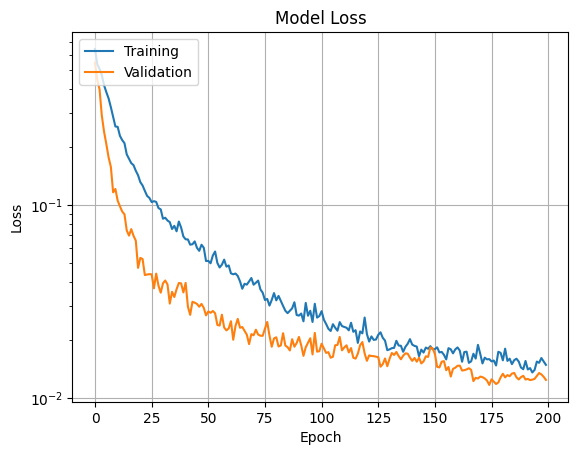

In [9]:
plt.semilogy(history.history['loss'])

if (Validation_Percentage > 0):
    plt.semilogy(history.history['val_loss'])

plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Training','Validation'], loc='upper left')
plt.grid(True)
plt.show()


### Model verification

* The following code uses the trained model to check the deviation for each picture (train + validation).
* The accepted_deviation can be used to get the accuracy with allowed differences (for instance +/- 0.1)
* The first (max) 49 false predicted images will be shown
* A csv-file with all false predicted images will be created. It can be used for relabeling with this tool: https://github.com/haverland/collectmeteranalog

In [10]:
# Parameters
accepted_deviation = 0.1


# Predict
classes = model.predict(x_data.astype(np.float32), verbose=0)
predicted_sin = classes[:, 0]
predicted_cos = classes[:, 1]

# Convert to values in [0, 10)
predicted_val = (np.arctan2(predicted_sin, predicted_cos) / (2 * math.pi) % 1) * 10.0 # Scale to 0 .. 10
expected_val = np.array(y_data_target * 10.0) # Scale to 0 .. 10
# Wrap: 9.9 <> 0 = 0.1 and 1.1 <> 1.2 = 0.1
deviation_val = np.minimum(np.abs(predicted_val - expected_val), np.abs(predicted_val - (10.0 - expected_val)))

# Round values
predicted_val = np.round(predicted_val, 1)
expected_val = np.round(expected_val, 1)
deviation_val = np.round(deviation_val, 1)

# Gater false predicted elements larger than configured delta
false_predicted_mask = deviation_val > accepted_deviation

false_predicted_dev_values = deviation_val[false_predicted_mask]
false_predicted_expected_values = expected_val[false_predicted_mask]
false_predicted_pred_values = predicted_val[false_predicted_mask]
false_predicted_images = x_data[false_predicted_mask]
#false_predicted_files = [f for f in f_data[false_predicted_mask]]
false_predicted_files = [Path(f).name for i, f in enumerate(f_data) if false_predicted_mask[i]]
false_predicted_plt_labels = [ 
    "Expected: " + str(y1) + "\n Predicted: " + str(p) + "\n" + str(Path(f).name[:-4][:20])
    for y1, p, f in zip(expected_val[false_predicted_mask], predicted_val[false_predicted_mask], f_data[false_predicted_mask])
]

# Sort by deviation (largest first)
sorted_indices = np.argsort(false_predicted_dev_values)[::-1]  # This sorts in descending order

false_predicted_dev_values = false_predicted_dev_values[sorted_indices]
false_predicted_expected_values = false_predicted_expected_values[sorted_indices]
false_predicted_pred_values = false_predicted_pred_values[sorted_indices]
false_predicted_images = false_predicted_images[sorted_indices]
false_predicted_plt_labels = [false_predicted_plt_labels[i] for i in sorted_indices]
false_predicted_files = [false_predicted_files[i] for i in sorted_indices]


Accuracy: 86.95 % (Images: 1739 | False Predicted: 227) | Accepted Deviation: 0.1


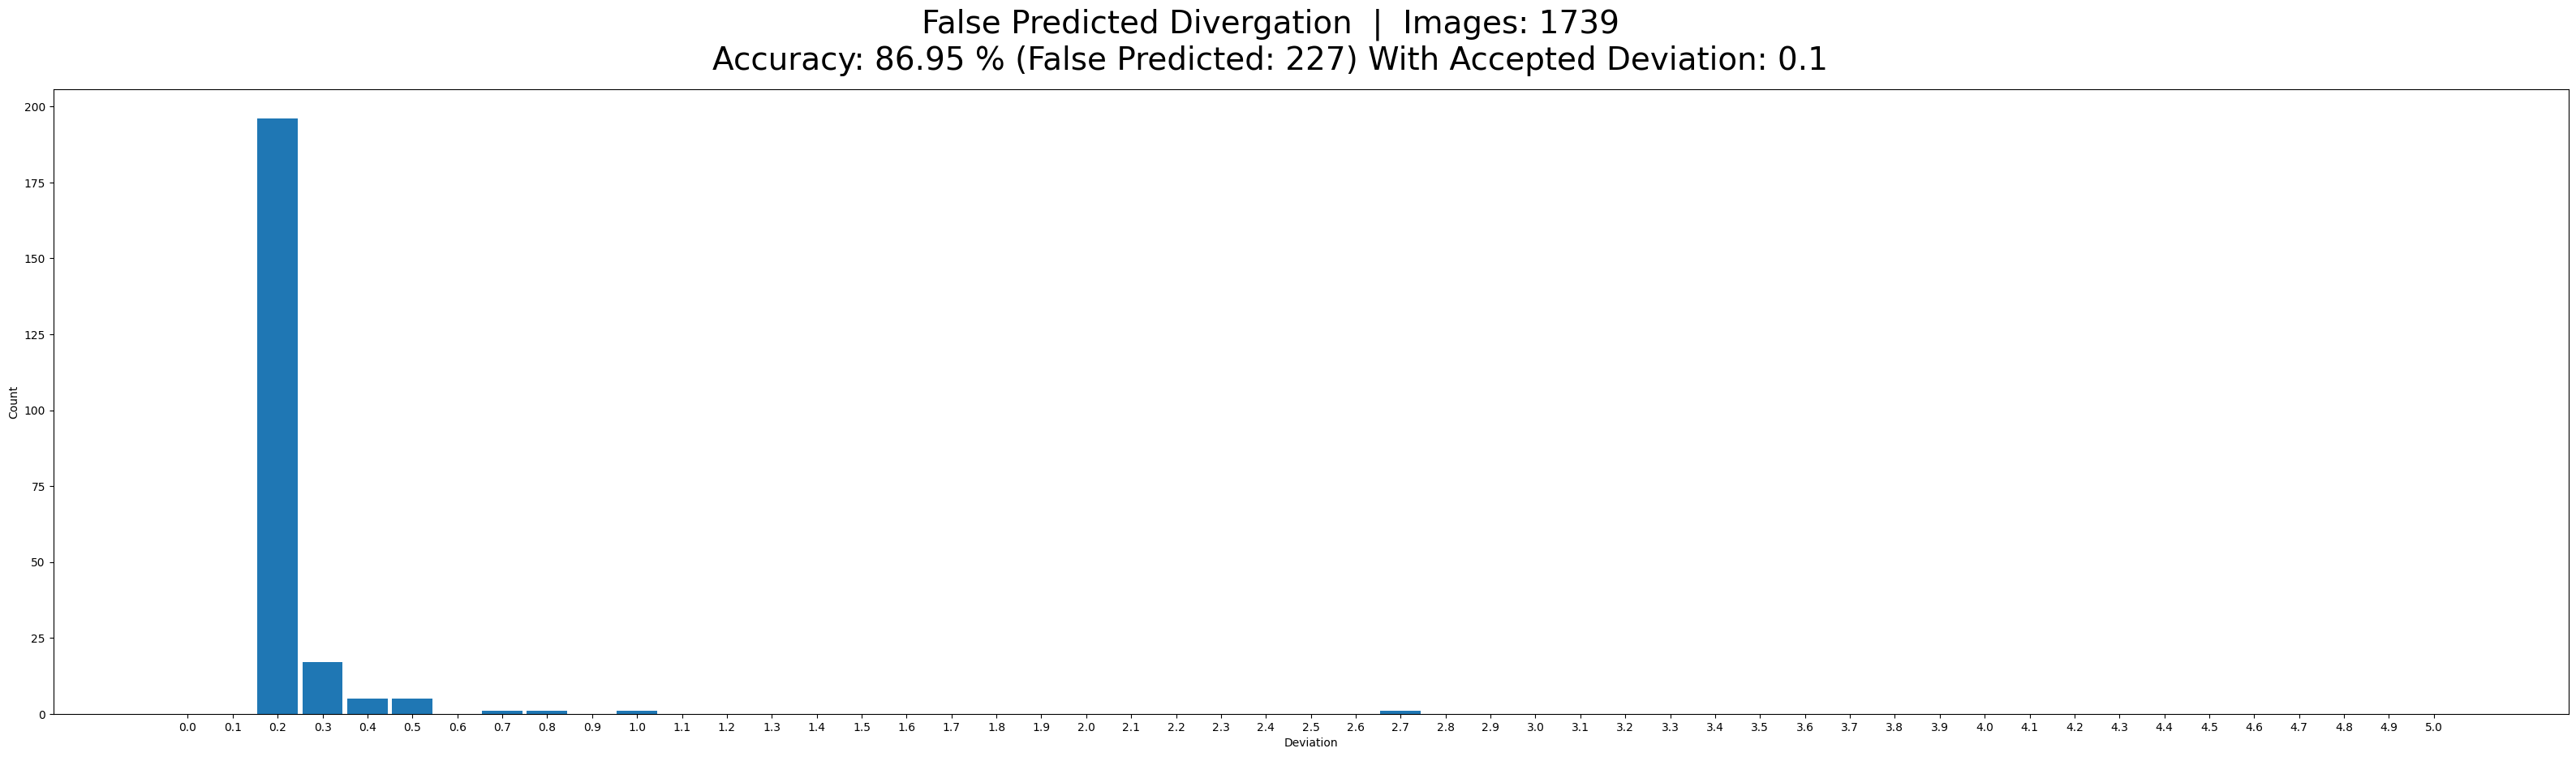

In [11]:
# Plot False Predicted Divergation
print(f"Accuracy: {(1 - len(false_predicted_dev_values) / len(y_data)) * 100.0:.2f} % (Images: {len(y_data)} | False Predicted: {len(false_predicted_dev_values)}) | Accepted Deviation: {accepted_deviation}")

title = f"False Predicted Divergation  |  Images: {len(y_data)}\nAccuracy: {(1 - len(false_predicted_dev_values) / len(y_data)) * 100.0:.2f} % (False Predicted: {len(false_predicted_dev_values)}) With Accepted Deviation: {accepted_deviation}"
_ = plot_divergence(np.bincount(np.array(np.round((np.abs(false_predicted_dev_values) * 10) % 51).astype(int)), minlength=51), title)


False Predictions (Sorted by highest deviation, max. 49 images)


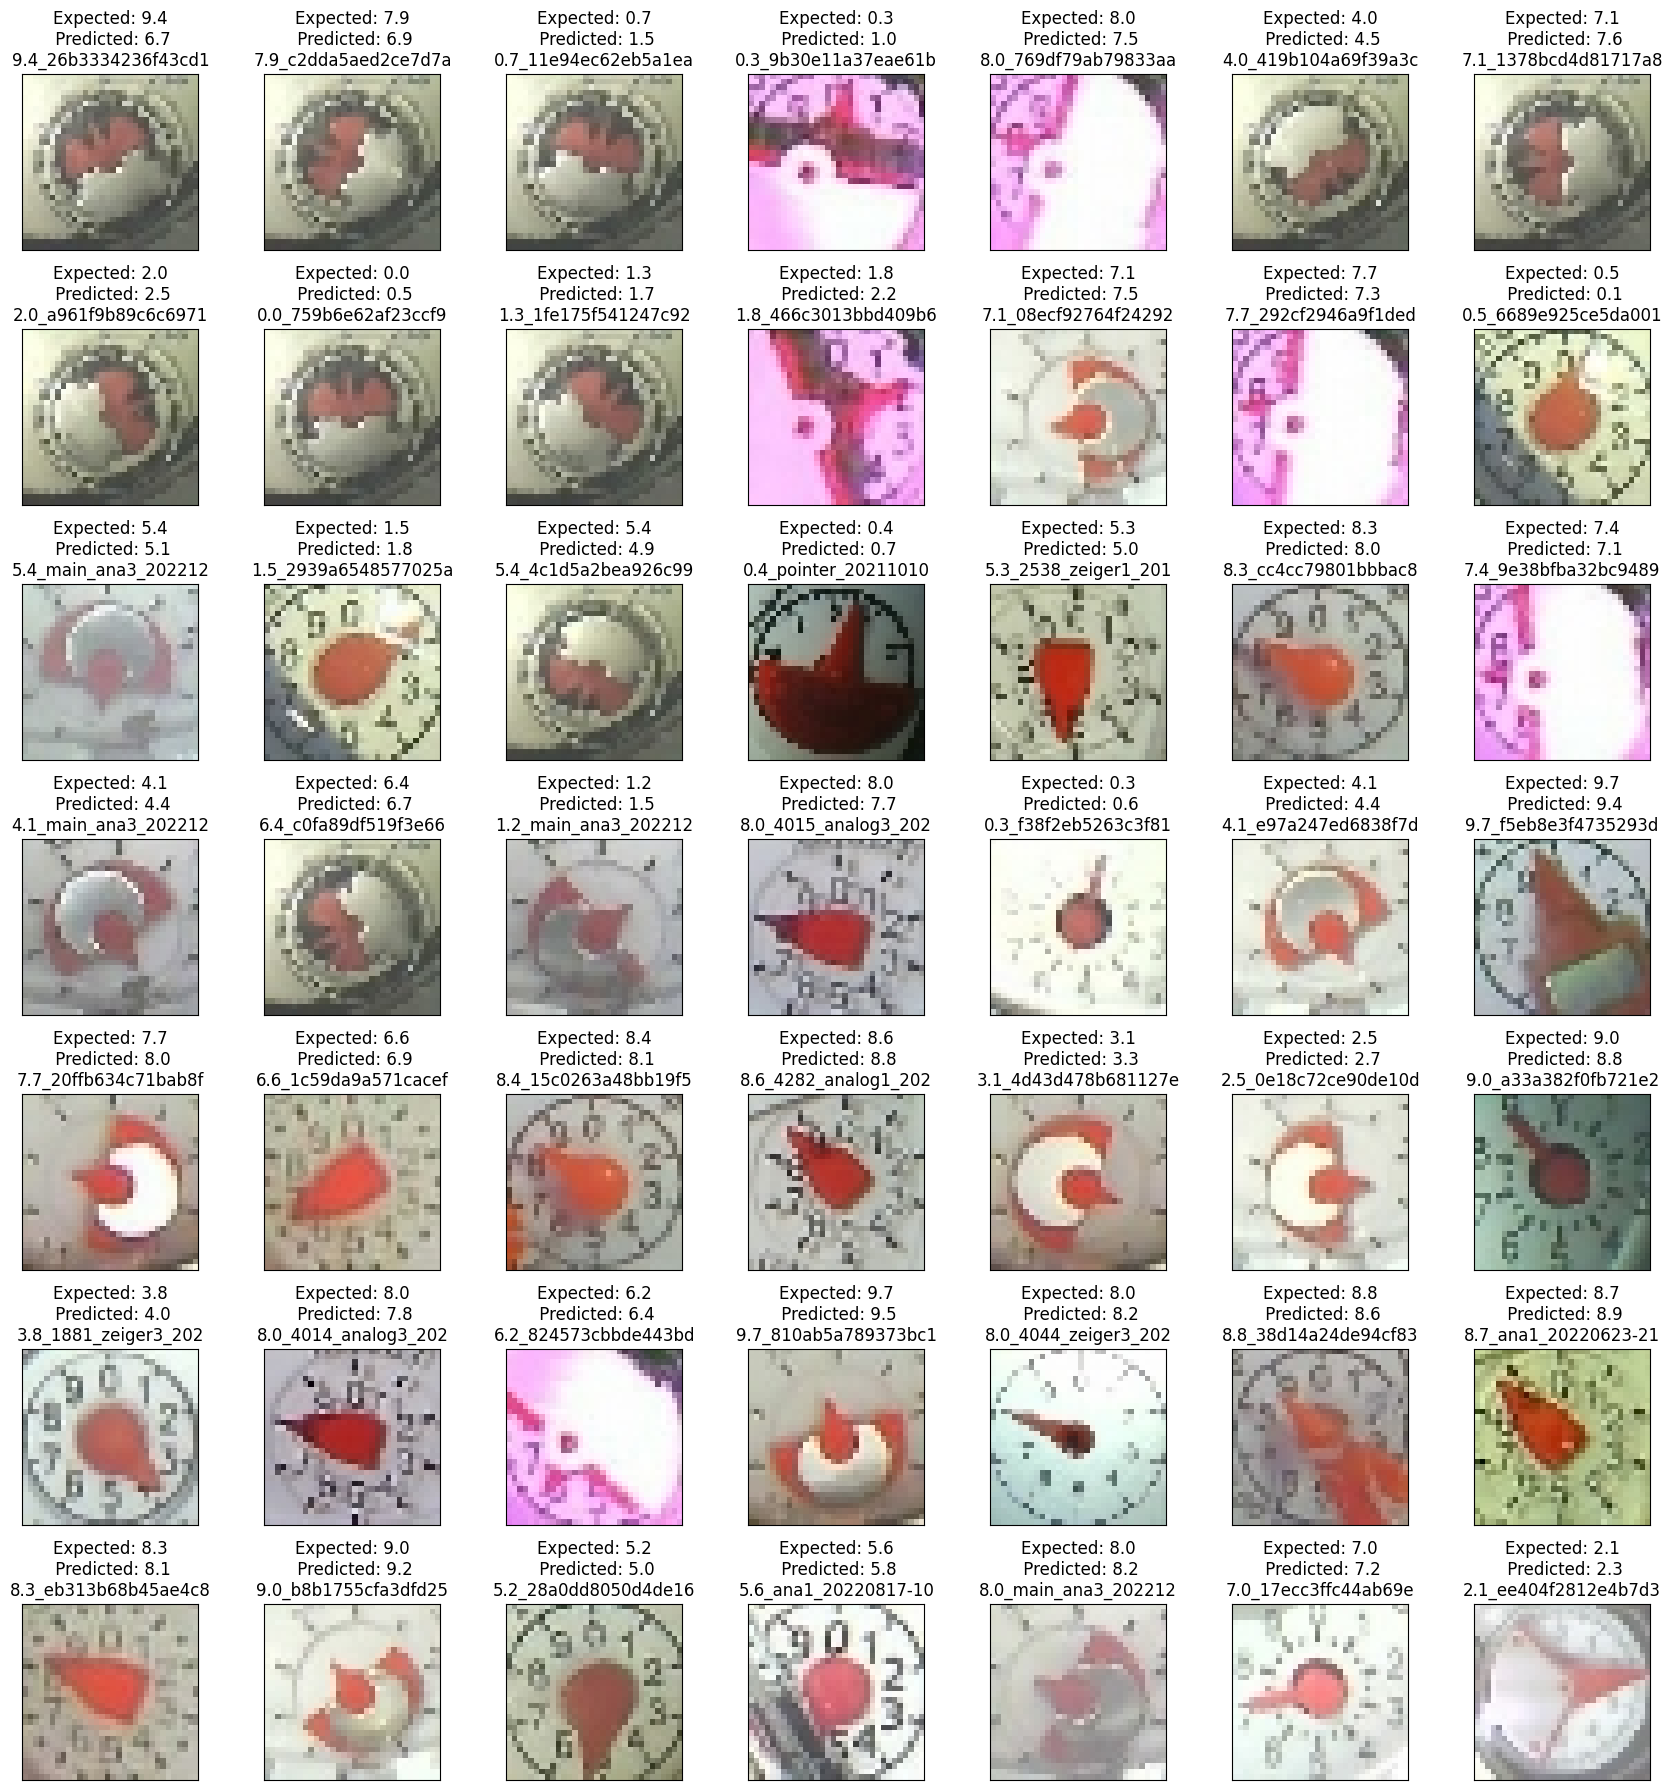

In [12]:
# Plot the dataset of false predictions (Use first 49 entries)
print("False Predictions (Sorted by highest deviation, max. 49 images)")
plot_dataset_analog_result(false_predicted_images, false_predicted_plt_labels, columns=7, rows=7, figsize=(18,18))


In [13]:
# Save false predicted image list to CSV
# The csv file can be further processed with the tool [collectmeteranalog](https://github.com/haverland/collectmeteranalog) to evaluate or adjust labels

csv_dir = f"{Output_Dir}/training_details/{TFlite_MainType}_{TFlite_Size}_{TFlite_Version}/"
Path(csv_dir).mkdir(parents=True, exist_ok=True)  # Create csv folder if it doesn't exist

false_predicted_df = pd.DataFrame(list(zip(false_predicted_files, false_predicted_pred_values, false_predicted_expected_values, 
                                  false_predicted_dev_values)), columns=["File", "Predicted", "Expected", "Deviation"])
false_predicted_df.to_csv(f"{csv_dir}/{TFlite_MainType}_{TFlite_Version}_{TFlite_Size}_false_predicted.csv", index=True, index_label="Index")


###############################################################################################################################################################################
# Save false predicted image list to CSV (--> LEGACY File Syntax)
# The csv file can be further processed with the tool [collectmeteranalog](https://github.com/haverland/collectmeteranalog) to evaluate or adjust labels

#false_predicted_df = pd.DataFrame(false_predicted_files)
#false_predicted_df.to_csv(f"{csv_dir}/{TFlite_MainType}_{TFlite_Version}_{TFlite_Size}_false_predicted.csv", index=True)


### Save the model

* Save the model to the file with the "tflite" file format
* quantize the model and store it as _q.tflite

In [14]:
FileName = f"{Output_Dir}/{TFlite_MainType}_{TFlite_Version}_{TFlite_Size}.tflite"

# TensorFlow Lite conversion
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

# Save the converted model
with open(FileName, "wb") as f:
    f.write(tflite_model)

print(f"Model saved successfully. File: {FileName}")
print(f"File size: {Path(FileName).stat().st_size} bytes")


INFO:tensorflow:Assets written to: /tmp/tmpx5sm7c6s/assets


INFO:tensorflow:Assets written to: /tmp/tmpx5sm7c6s/assets


Saved artifact at '/tmp/tmpx5sm7c6s'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 32, 32, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  140593331775120: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140593331774736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140593331773008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140593331772816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140593331775312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140593331775888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140593331774544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140593331776080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140593331776656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140593331774352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140593331776848:

W0000 00:00:1748287325.085109    2224 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1748287325.085142    2224 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.


Model saved successfully. File: models_tmp/ana-cont_tests3_s3.tflite
File size: 143984 bytes


2025-05-26 19:22:05.085396: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpx5sm7c6s
2025-05-26 19:22:05.086668: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2025-05-26 19:22:05.086682: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmpx5sm7c6s
I0000 00:00:1748287325.099675    2224 mlir_graph_optimization_pass.cc:401] MLIR V1 optimization pass is not enabled
2025-05-26 19:22:05.101780: I tensorflow/cc/saved_model/loader.cc:236] Restoring SavedModel bundle.
2025-05-26 19:22:05.174648: I tensorflow/cc/saved_model/loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmpx5sm7c6s
2025-05-26 19:22:05.194882: I tensorflow/cc/saved_model/loader.cc:466] SavedModel load for tags { serve }; Status: success: OK. Took 109487 microseconds.
2025-05-26 19:22:05.212735: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, 

In [15]:
FileName = f"{Output_Dir}/{TFlite_MainType}_{TFlite_Version}_{TFlite_Size}_q.tflite"

# Representative dataset function
def representative_dataset():
    for n in range(x_data[0].shape[0]):
        data = np.expand_dims(x_data[n], axis=0)
        yield [data.astype(np.float32)]

# TensorFlow Lite conversion with optimizations
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_dataset
converter._experimental_disable_per_channel_quantization_for_dense_layers = True
tflite_quant_model = converter.convert()

# Save the converted model to the specified file
with open(FileName, "wb") as f:
    f.write(tflite_quant_model)

print(f"Model saved successfully. File: {FileName}")
print(f"File size: {Path(FileName).stat().st_size} bytes")


INFO:tensorflow:Assets written to: /tmp/tmpwq2b4gct/assets


INFO:tensorflow:Assets written to: /tmp/tmpwq2b4gct/assets


Saved artifact at '/tmp/tmpwq2b4gct'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 32, 32, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  140593331775120: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140593331774736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140593331773008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140593331772816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140593331775312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140593331775888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140593331774544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140593331776080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140593331776656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140593331774352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140593331776848:

/home/runner/work/neural-network-analog-needle-readout/neural-network-analog-needle-readout/.venv/lib/python3.11/site-packages/tensorflow/lite/python/convert.py:997: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


Model saved successfully. File: models_tmp/ana-cont_tests3_s3_q.tflite
File size: 46480 bytes


W0000 00:00:1748287326.057850    2224 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1748287326.057871    2224 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
2025-05-26 19:22:06.058031: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpwq2b4gct
2025-05-26 19:22:06.059494: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2025-05-26 19:22:06.059510: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmpwq2b4gct
2025-05-26 19:22:06.074477: I tensorflow/cc/saved_model/loader.cc:236] Restoring SavedModel bundle.
2025-05-26 19:22:06.145864: I tensorflow/cc/saved_model/loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmpwq2b4gct
2025-05-26 19:22:06.166539: I tensorflow/cc/saved_model/loader.cc:466] SavedModel load for tags { serve }; Status: success: OK. Took 108512 microseconds.
fully_quantize: 0, inference_type: 6, input_